In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


In [2]:
df = pd.read_csv("student-por.csv")

print("Shape:", df.shape)
print(df.head())


Shape: (649, 33)
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        4   0  11  11  
1      5        3      3     1     1      3        2   9  11  11  
2      4        3      2     2     3      3        6  12  13  12  
3      3        2      2     1     1      5        0  14  14  14  
4      4        3      2     1     2      5        0  11  13  13  

[5 rows x 33 columns]


In [3]:
print(df.info())
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [4]:
df = df.drop(columns=["G1", "G2"])

df["Pass"] = (df["G3"] >= 10).astype(int)

X = df.drop(columns=["G3", "Pass"])
y = df["Pass"]

print(y.value_counts())


Pass
1    549
0    100
Name: count, dtype: int64


In [5]:
X = pd.get_dummies(X, drop_first=True)

print(X.shape)


(649, 39)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)


Training: (519, 39)
Testing: (130, 39)


In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [8]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print(classification_report(y_test, y_pred_lr))


              precision    recall  f1-score   support

           0       0.29      0.25      0.27        20
           1       0.87      0.89      0.88       110

    accuracy                           0.79       130
   macro avg       0.58      0.57      0.57       130
weighted avg       0.78      0.79      0.79       130



In [9]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print(classification_report(y_test, y_pred_dt))


              precision    recall  f1-score   support

           0       0.24      0.20      0.22        20
           1       0.86      0.88      0.87       110

    accuracy                           0.78       130
   macro avg       0.55      0.54      0.54       130
weighted avg       0.76      0.78      0.77       130



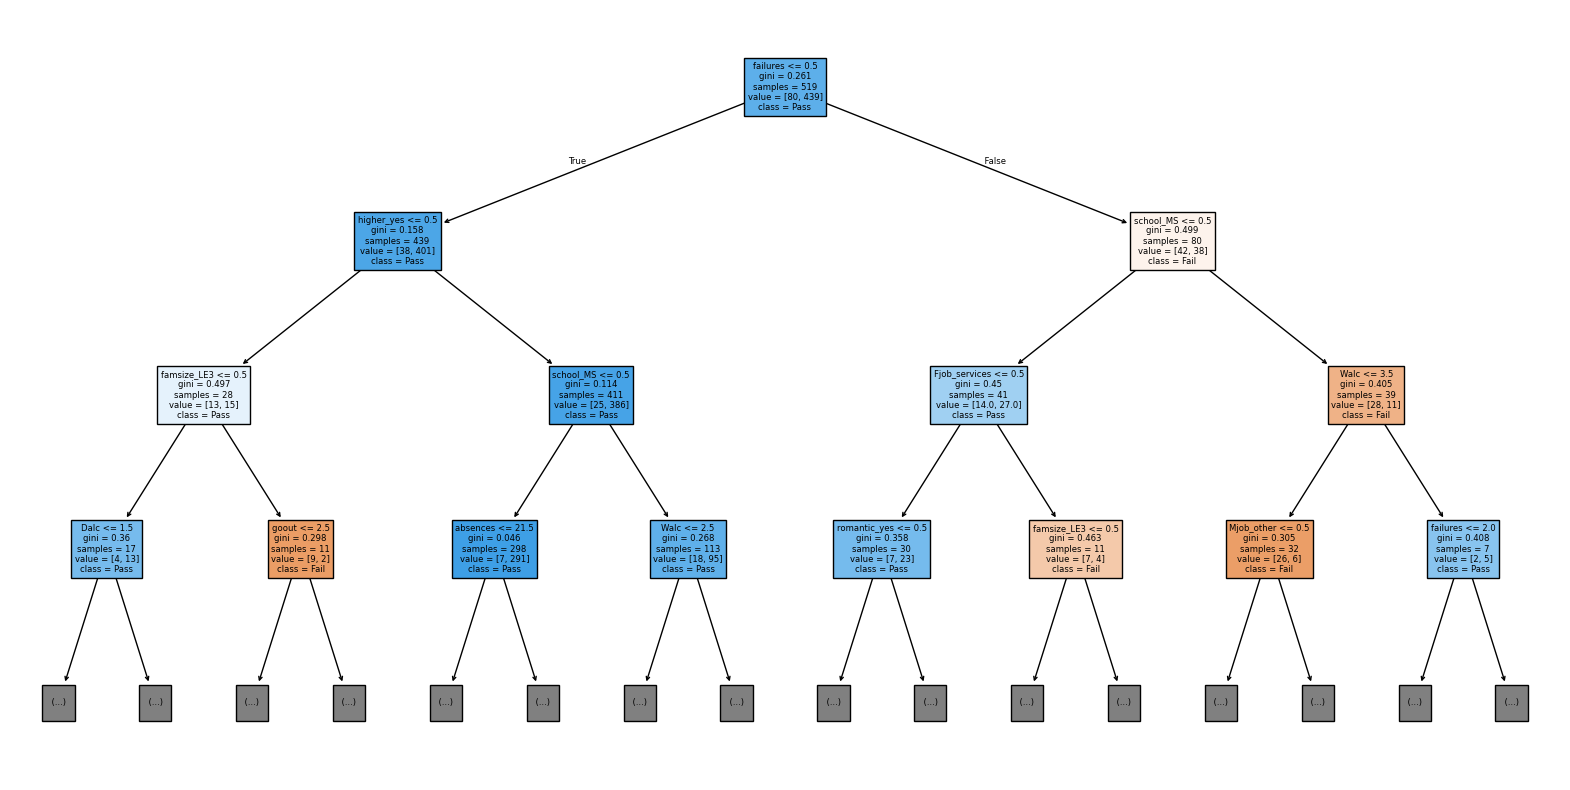

In [10]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["Fail", "Pass"],
    filled=True,
    max_depth=3
)

plt.show()

In [11]:
nb = GaussianNB()

nb.fit(X_train_scaled, y_train)

y_pred_nb = nb.predict(X_test_scaled)

print(classification_report(y_test, y_pred_nb))


              precision    recall  f1-score   support

           0       0.21      0.50      0.30        20
           1       0.88      0.66      0.76       110

    accuracy                           0.64       130
   macro avg       0.55      0.58      0.53       130
weighted avg       0.78      0.64      0.69       130



In [12]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Naive Bayes"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_nb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_nb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_nb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_nb)
    ]
})

print(results)


                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.792308   0.867257  0.890909  0.878924
1        Decision Tree  0.776923   0.858407  0.881818  0.869955
2          Naive Bayes  0.638462   0.879518  0.663636  0.756477


In [14]:
best_model = results.loc[results["F1 Score"].idxmax()]

print("Best Performing Algorithm:", best_model["Model"])
print("F1 Score:", best_model["F1 Score"])


Best Performing Algorithm: Logistic Regression
F1 Score: 0.8789237668161435


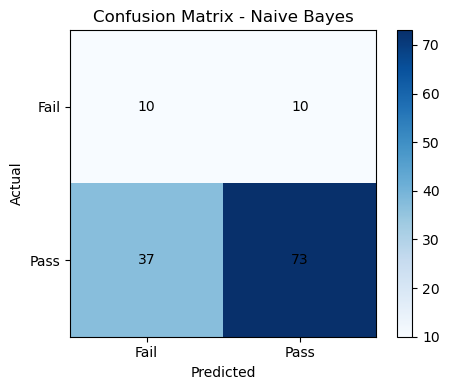

In [17]:

cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(5, 4))
plt.imshow(cm_nb, cmap="Blues")

plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Fail", "Pass"])
plt.yticks([0, 1], ["Fail", "Pass"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_nb[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

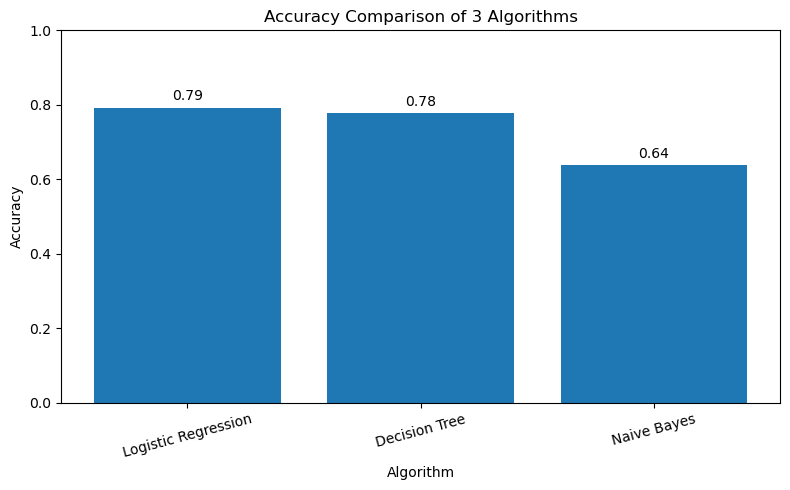

In [16]:
# Comparison Graph - 3 Algorithms
models = ["Logistic Regression", "Decision Tree", "Naive Bayes"]
accuracies = [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_nb)]
plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)
plt.title("Accuracy Comparison of 3 Algorithms")
plt.xlabel("Algorithm")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
for i, value in enumerate(accuracies): plt.text(i, value + 0.02, f"{value:.2f}", ha="center")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
